# 1- Understand the Buisness Problem

## 1. **Introduction**


**What is Customer Churn?**

Customer churn is defined as when customers or subscribers discontinue doing business with a firm or service.

Customers in the telecom industry can choose from a variety of service providers and actively switch from one to the next. The telecommunications business has an annual churn rate of 15-25 percent in this highly competitive market.

Individualized customer retention is tough because most firms have a large number of customers and can't afford to devote much time to each of them. The costs would be too great, outweighing the additional revenue. However, if a corporation could forecast which customers are likely to leave ahead of time, it could focus customer retention efforts only on these "high risk" clients. The ultimate goal is to expand its coverage area and retrieve more customers loyalty. The core to succeed in this market lies in the customer itself.

Customer churn is a critical metric because it is much less expensive to retain existing customers than it is to acquire new customers.


To reduce customer churn, telecom companies need to predict which customers are at high risk of churn.

To detect early signs of potential churn, one must first develop a holistic view of the customers and their interactions across numerous channels, including store/branch visits, product purchase histories, customer service calls, Web-based transactions, and social media interactions, to mention a few.

As a result, by addressing churn, these businesses may not only preserve their market position, but also grow and thrive. More customers they have in their network, the lower the cost of initiation and the larger the profit. As a result, the company's key focus for success is reducing client attrition and implementing effective retention strategy.


Objectives ▶

I will explore the data and try to answer some questions like:

* What's the % of Churn Customers and customers that keep in with the active services?
* Is there any patterns in Churn Customers based on the gender?
* Is there any patterns/preference in Churn Customers based on the type of service provided?
* What's the most profitable service types?
* Which features and services are most profitable?
* Many more questions that will arise during the analysis

##  1.1 Importing Libraries And DataSet

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


## 1.2 Data Cleaning preparation



2.1 Data type Correction

In [2]:
dataset = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
dataset = dataset.drop('customerID',axis=1)
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

In [3]:
dataset.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

2.2 Missing Values

In [4]:
dataset.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

 Handling Constant in numerical Feature

In [5]:
#Code for transform text to number
bin_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
for col in bin_cols:
    dataset[col]=dataset[col].map({"Yes":1, "No":0, "Male":1, "Female":0})

multi_cols= ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod"]
dataset = pd.get_dummies(dataset, columns = multi_cols, drop_first= True)

In [6]:
for col in dataset.select_dtypes(include=["bool"]).columns:
    dataset[col]= dataset[col].astype(int)
dataset

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,0,0,0,0,1


 Describe Numerical Feature

In [7]:
numerical_features = ['TotalCharges','MonthlyCharges','tenure']
dataset[numerical_features].describe()

,TotalCharges,MonthlyCharges,tenure
count,7032.000000,7043.000000,7043.000000
mean,2283.300441,64.761692,32.371149
std,2266.771362,30.090047,24.559481
min,18.800000,18.250000,0.000000
25%,401.450000,35.500000,9.000000
50%,1397.475000,70.350000,29.000000
75%,3794.737500,89.850000,55.000000
max,8684.800000,118.750000,72.000000


## 1.3 Exploratory data analysis

3.0 Categorical Data

In [8]:
cat_cols = [col for col in dataset.columns if dataset[col].nunique() <= 10 and col != "Churn"]

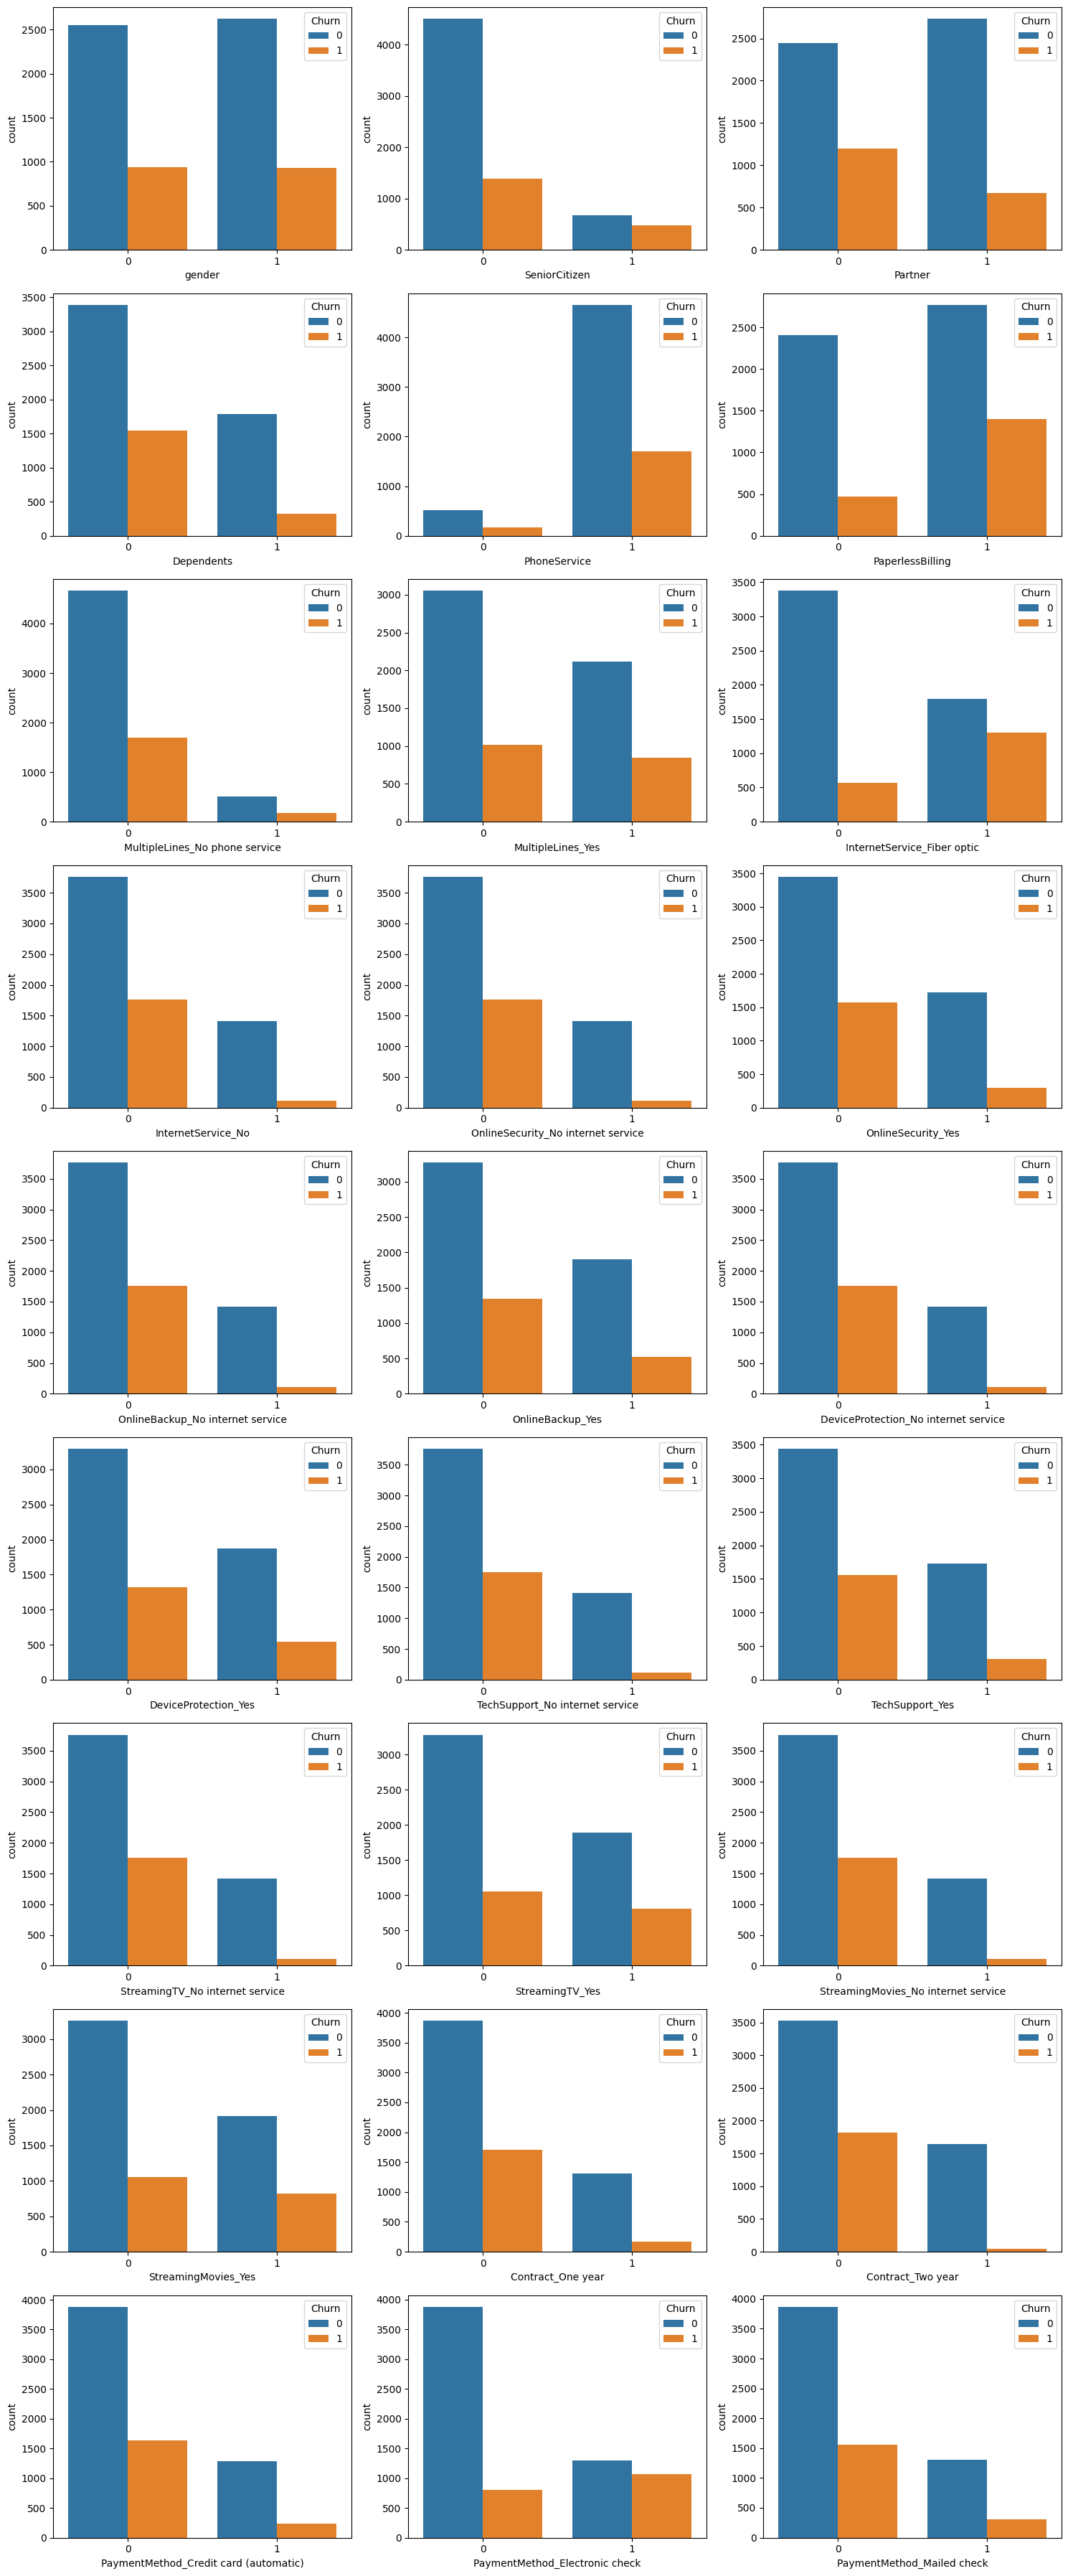

In [9]:
n_cols =  3
n_row = int(np.ceil(len(cat_cols)/n_cols))
fig, ax = plt.subplots(n_row,n_cols,figsize=(n_cols * 5, n_row * 4))
axes = ax.flatten()

for i ,col in enumerate(cat_cols):
    sns.countplot(x=col,hue= 'Churn',data=dataset,ax=axes[i])
plt.tight_layout()
plt.show()

The countplots reveal several categorical features with notable differences in churn rates across categories ▶

* **Contract type:** Shows a strong relationship with churn. Customers with
month-to-month contracts have much higher churn rates, while those with one or two year contracts are less likely to churn.

* **Payment method:** Customers paying via eletronic check exhibit significantly higher churn compared to those using credit cards, bank transfers, or mailed checks.

* **Internet Service type and related add-ons:** (Such as OnlineSecurity, TechSupport, and DeviceProtection) also correlate with churn, customers without these services tend to have higher churn.

* **PaperlessBilling:** Is associated with higher churn, possibly because it correlates with other factors like payment method or contract type.

* **Demographic variables** like SeniorCitizen, Partne and dependents show smaller but still visible differences in churn rates.

* **Churn** Indicates a imbalanced dataset.


**Conclusion** ▶
* **Tenure vs Churn** Higher tenure rate = No and Low = Yes.
* **Monthly Charges** People paying more monthly bills = Yes and and less = No.
* **Total Charges** People paying less charges = Yes and paying more chages No.

3.1 Numerical

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


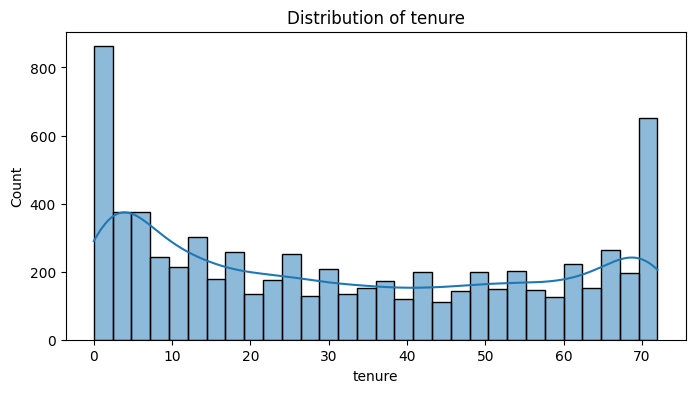

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


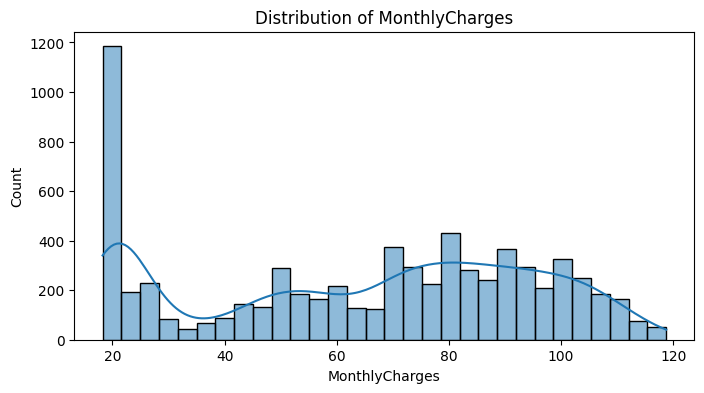

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


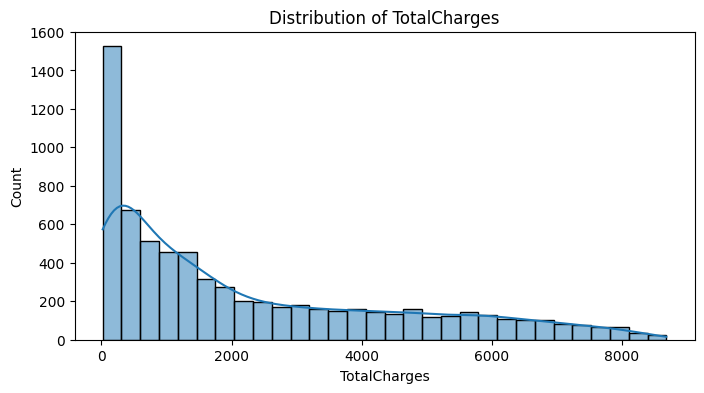

In [10]:
num_cols= ["tenure","MonthlyCharges","TotalCharges"]
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(dataset[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

Conclusion ▶


*   **Distribution of Tenure** Graph is telling that 10-20 counts and 60-72 counts are high comparing from median indicates most number of people are between these ranges.
*   **Distribution of Monthly** Graph is skewed to the left means most of people are clustered around lower bound and there are few people who are paying high bills.
*   **Total Charges** Again data is clustered in the right lower bounds 0-2000, and heavily right skewed .



3.2 Distrubution of Churn

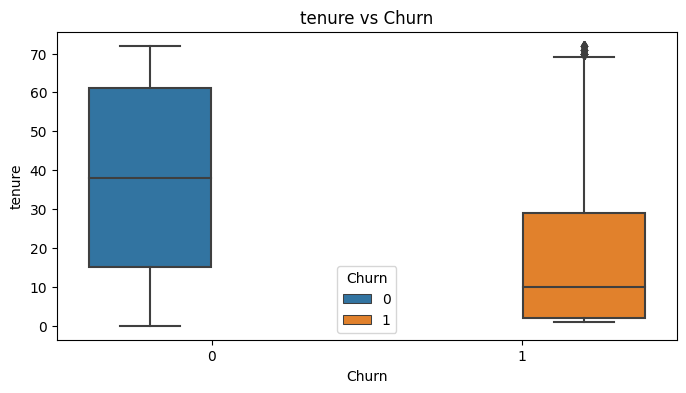

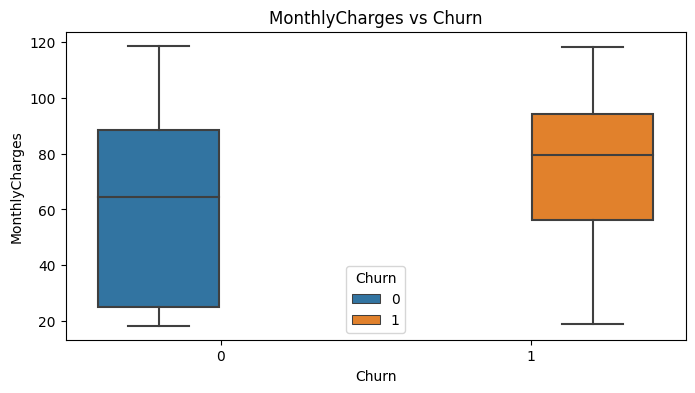

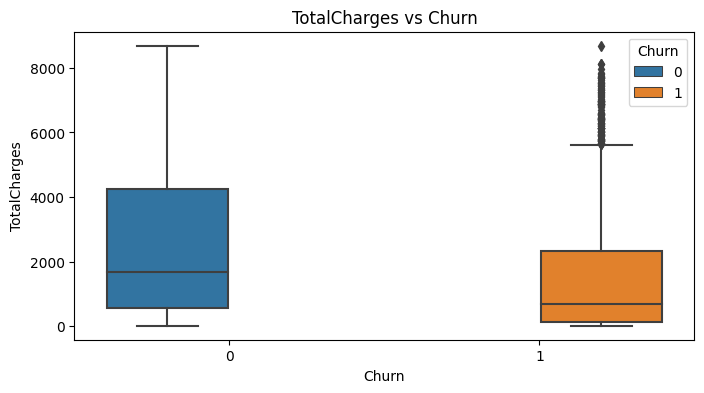

In [11]:
for col in num_cols:
  plt.figure(figsize=(8,4))
  sns.boxplot(x= 'Churn',y =col,data = dataset,hue="Churn")
  plt.title(f"{col} vs Churn")
  plt.show()

**Conclusion** ▶
* **Tenure vs Churn** Higher tenure rate = No and Low = Yes.
* **Monthly Charges** People paying more monthly bills = Yes and and less = No.
* **Total Charges** People paying less charges = Yes and paying more chages No.

**Total Charges** have significant number of outliers. And data is really mixed up it has linear relation but we will miss lot of values because of mixed up data.The outliers here are some random people who left there services.



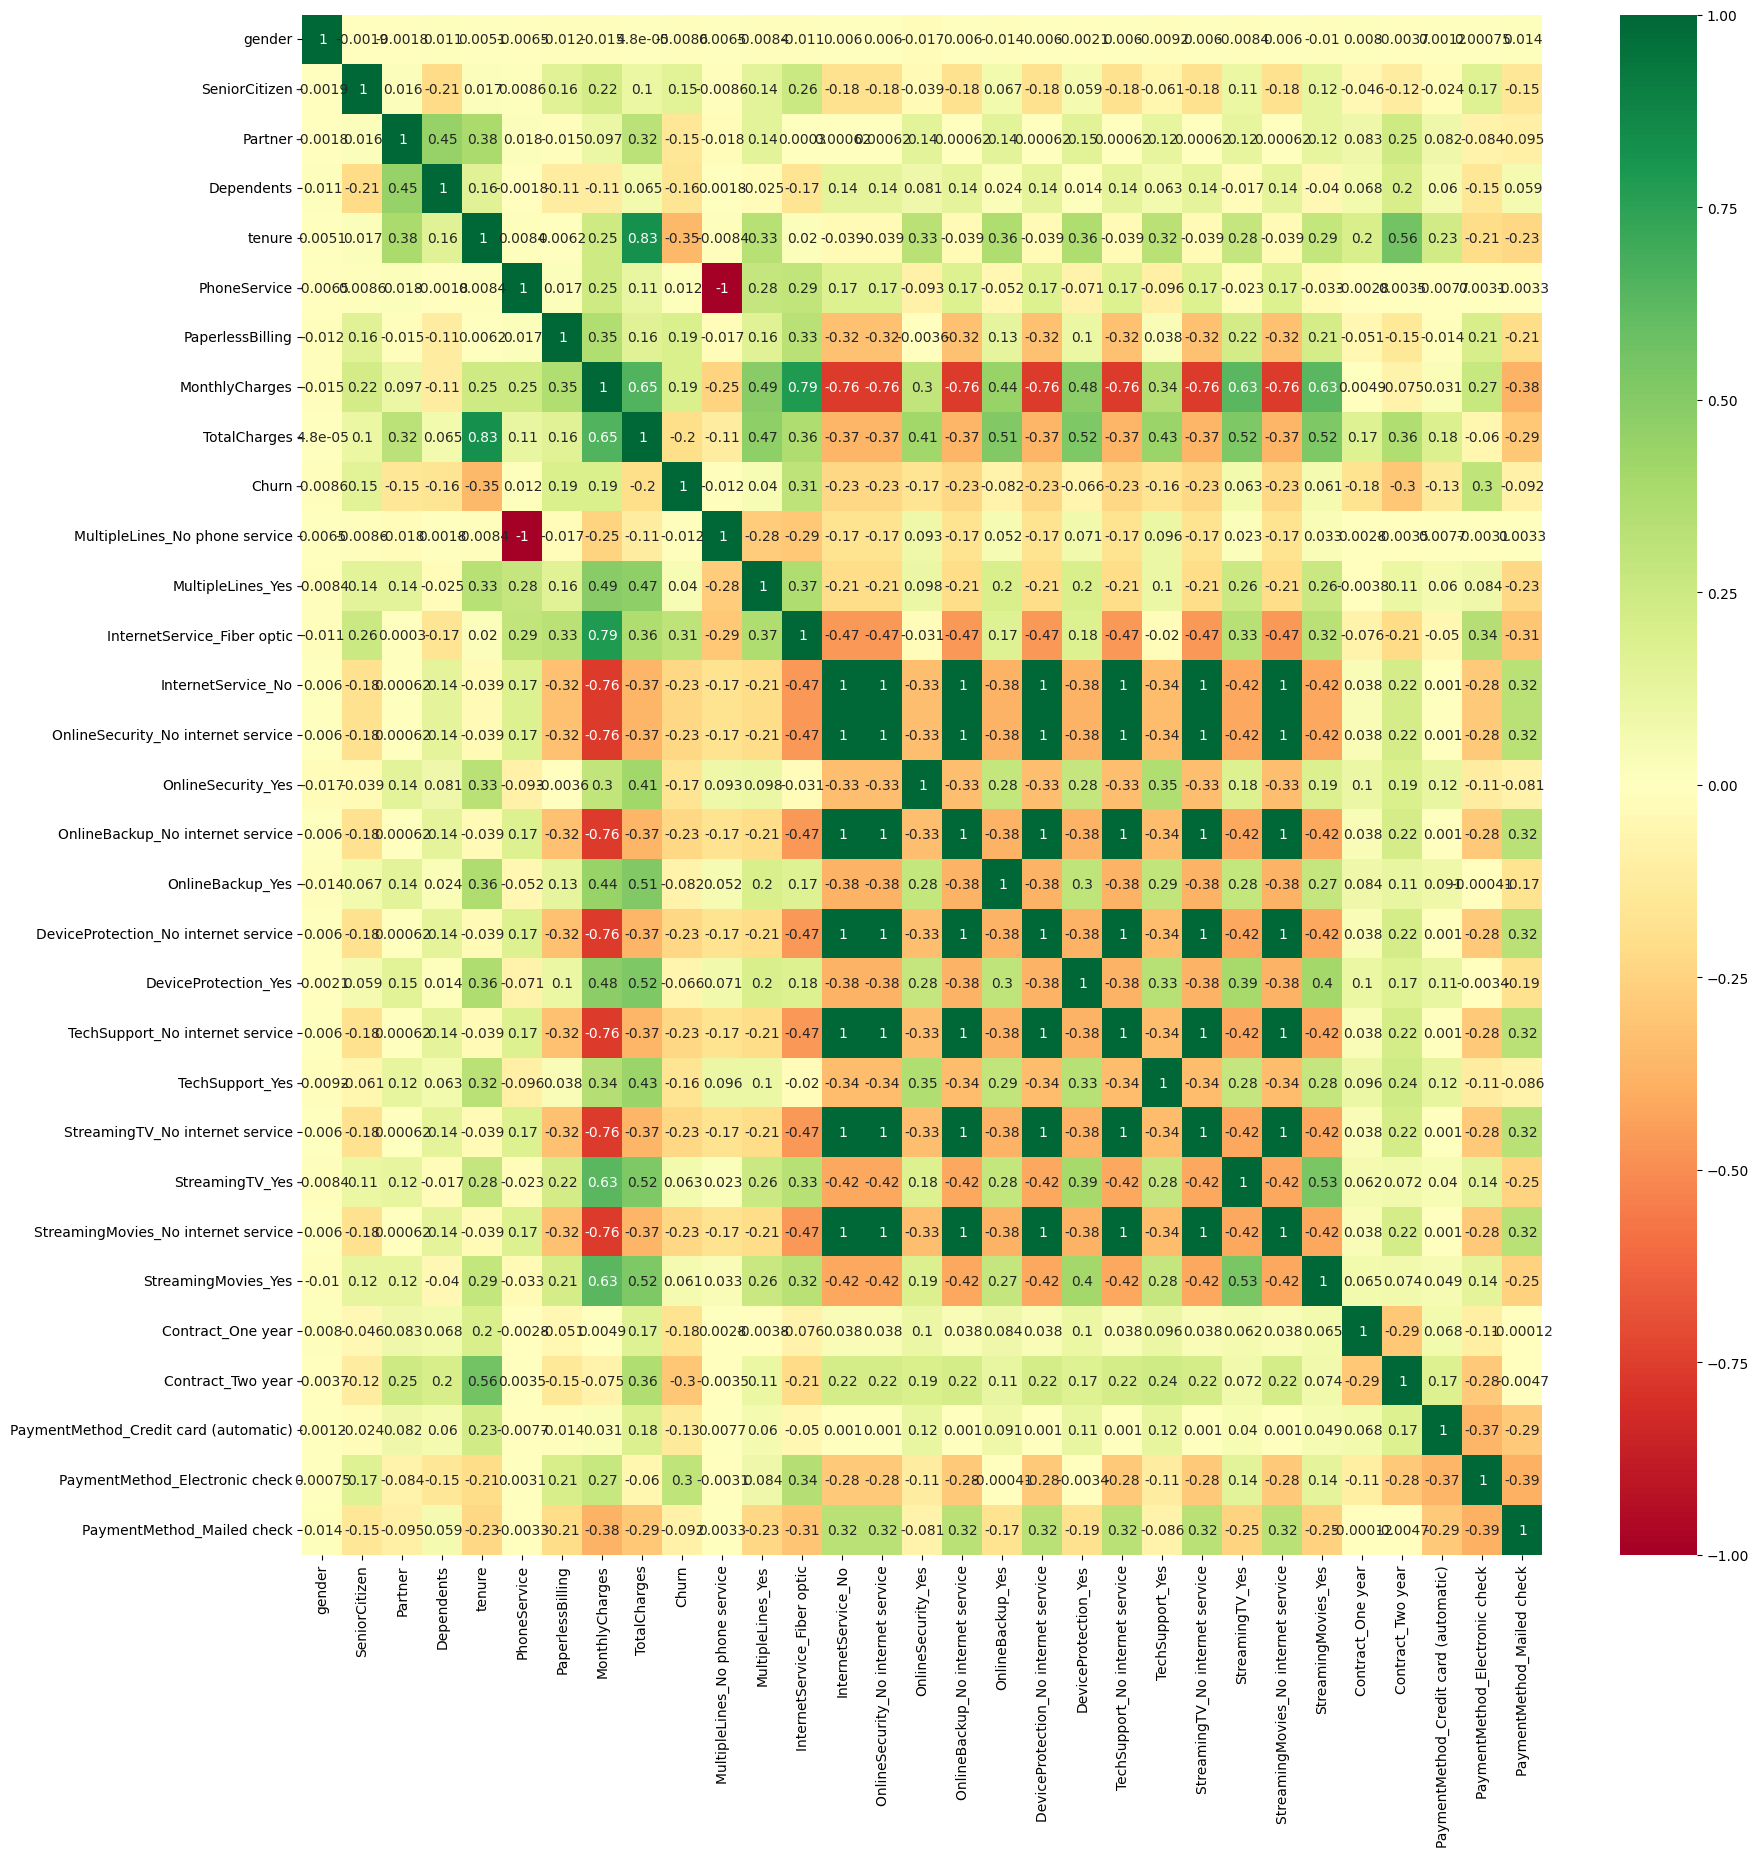

In [12]:
import seaborn as sns
#get correlations of each features in dataset
corrmat = dataset.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(dataset[top_corr_features].corr(),annot=True,cmap="RdYlGn")

# 2- Feature scaling

In [13]:
X = dataset.drop('Churn',axis=1) # Independent Variable
y = dataset['Churn'] # Target Variable

In [14]:
# Impute missing values in X before applying SMOTE
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X['TotalCharges'] = imputer.fit_transform(X[['TotalCharges']])

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2.1 Scaling The Data

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3-Model Trainnig

In [17]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_classifier =RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [18]:
#Create and train LightGBM
from lightgbm import LGBMClassifier
lgbm_classifier = LGBMClassifier(random_state=42, verbose=-1)
#Train model
lgbm_classifier.fit(X_train, y_train)

LGBMClassifier(random_state=42, verbose=-1)

In [19]:
# Xgboost
from xgboost import XGBClassifier
xgb_classifier = XGBClassifier(random_state=42)
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

## 3.1 Baseline Model

In [20]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
def evaluate_model(name,model,x_test,y_test):
  y_pred = model.predict(x_test)
  y_proba = model.predict_proba(x_test)[:,1]

  # Acuuracy
  print(f"Model{name}")
  accuracy = accuracy_score(y_test,y_pred)
  print(f"Accuracy{accuracy}")

  # Classification
  print("Classification Report")
  print(f'Name:{name}')
  print(classification_report(y_test,y_pred))

  # Confusion Matrix
  print("Confusion Matrix")
  cm = confusion_matrix(y_test,y_pred)
  print(f'Name:{name}')
  sns.heatmap(cm,annot = True,fmt="d", cmap="Blues", cbar=False)
  plt.title(f"{name}Confusion Matrix")
  plt.xlabel("Prediction")
  plt.ylabel("True Values")
  plt.show()

  # ROC curve
  fpr, tpr, _ = roc_curve(y_test, y_proba)
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(5, 4))
  plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f' ROC curve - {name}')
  plt.legend(loc="lower right")
  plt.show()

  # Precision-Recall curve
  precision, recall, _ = precision_recall_curve(y_test, y_proba)
  plt.figure(figsize=(5, 4))
  plt.plot(recall, precision, color='green')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall curve - {name}')
  plt.grid()
  plt.show


##

## 3.2 Random Forest Classifier

ModelRandomForest
Accuracy0.7913413768630234
Classification Report
Name:RandomForest
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix
Name:RandomForest


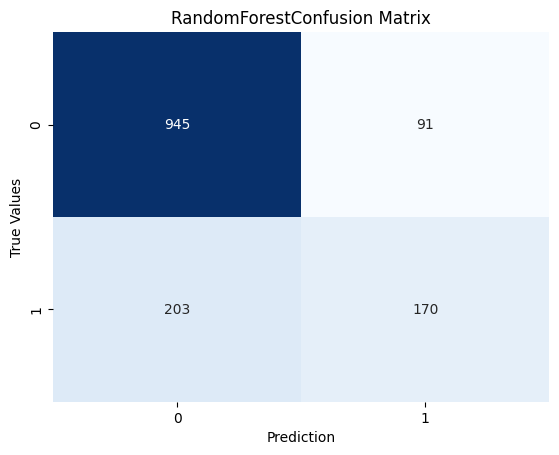

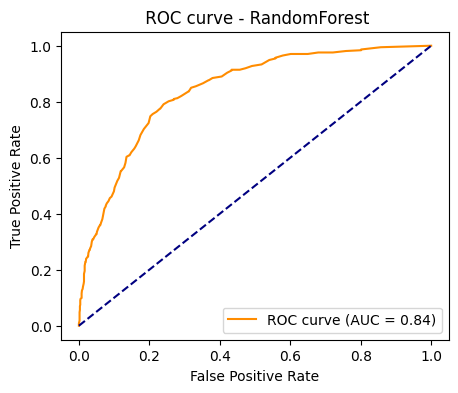

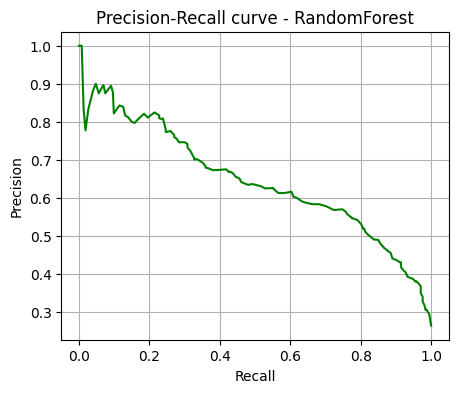

In [21]:
evaluate_model("RandomForest",rf_classifier,X_test,y_test)


Observation ▶


*   Class 1 prediction is 59 % the synthetic data is maybe copied together.
*   The algo is not understanding the class 1 data .



## 3.3 XGboost

ModelXGBOOST
Accuracy0.7984386089425124
Classification Report
Name:XGBOOST
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1036
           1       0.64      0.54      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix
Name:XGBOOST


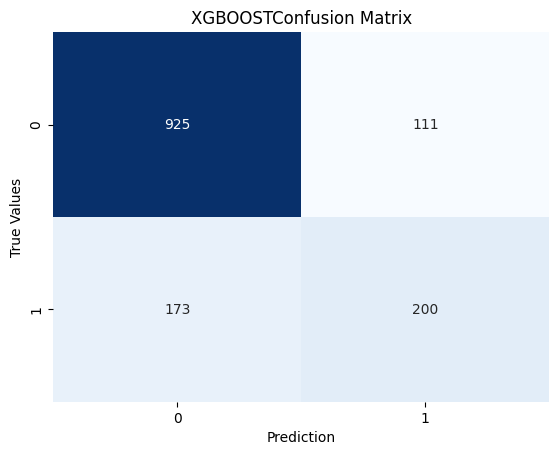

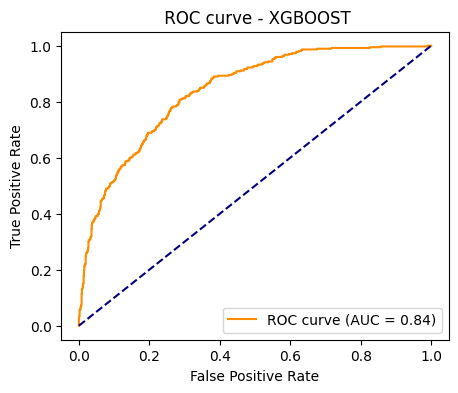

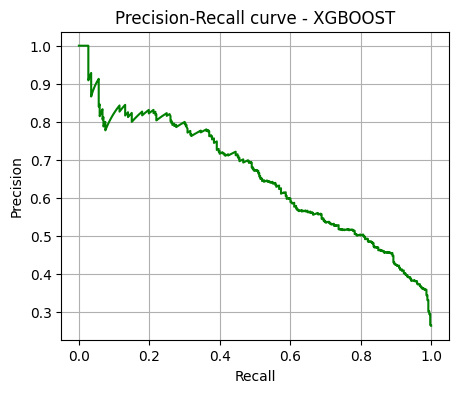

In [22]:
evaluate_model("XGBOOST",xgb_classifier,X_test,y_test)

Conclusion ▶


Classification Report :
*   **Accuracy** is 78% says We will predict Churn correctly 8 out of 10 times.
*   **Class 0**  Precision is (85) and recall is (85) indicates model is really good at predicting person who will stay.
*   **Class 1** Precision (59) and recall (61) Indicates model strugles to find person who will leave.


Confusion Matrix :
*   **Class 0** 878 Correct Prediction and 145 wrong Prediction.
*   **Class 1** 228 correct and 145 wrong .

Roc Curve :
*    Shows (83) Overall good discrimination ability between churnes and non Churnes.

Precision :
*   When recall is increasing the precision is falling.




## 3.4 LGBM

ModelLGBM
Accuracy0.8048261178140526
Classification Report
Name:LGBM
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

Confusion Matrix
Name:LGBM


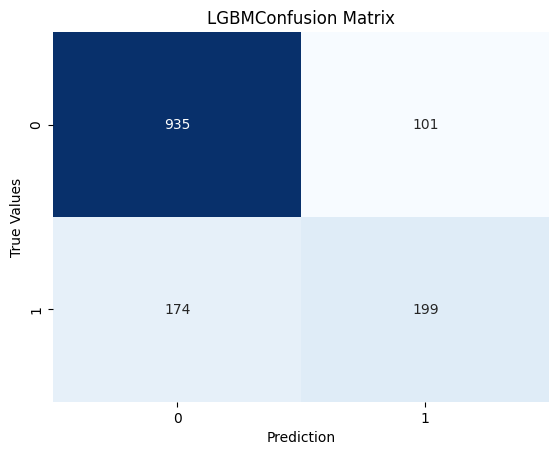

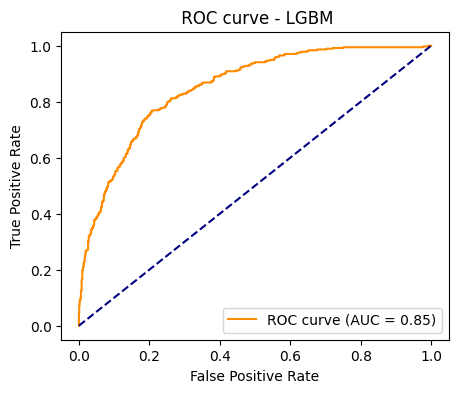

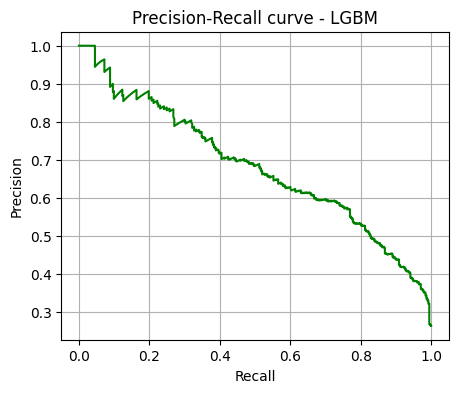

In [23]:
evaluate_model("LGBM",lgbm_classifier,X_test,y_test)

Conclusion ▶


Classification Report :
*   **Accuracy** is 79% says We will predict Churn correctly 8 out of 10 times.
*   **Class 0**  Precision is (86) and recall is (85) indicates model is really good at predicting person who will stay.
*   **Class 1** Precision (60) and recall (63) Indicates model strugles to find person who will leave.


Confusion Matrix :
*   **Class 0** 877 Correct Prediction and 159 wrong Prediction.
*   **Class 1** 234 correct and 139 wrong .

Roc Curve :
*    Shows (84) Overall good discrimination ability between churnes and non Churnes.

Precision :
*   When recall is increasing the precision is falling.




## 3.5 Tuning LGBM


Lgbm performing the best among them so we will tune LGBM for better Class 1 result.

In [24]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
from skopt import gp_minimize
from skopt.space import Real, Integer

# 1. Define the search space for the hyperparameters
search_space = [
    Integer(100, 1000, name='n_estimators'),
    Real(1e-3, 1e-1, prior='log-uniform', name='learning_rate'),
    Integer(20, 100, name='num_leaves'),
    Integer(-1, 20, name='max_depth'),
    Real(0.5, 1.0, name='subsample'),
    Real(0.5, 1.0, name='colsample_bytree')
]

# 2. Define the objective function to minimize
# This function takes the hyperparameters as input and returns the score to minimize (e.g., negative accuracy)
def objective_function(params):
    n_estimators, learning_rate, num_leaves, max_depth, subsample, colsample_bytree = params

    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42
    )

    # Use cross-validation to get a robust score
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    # We want to maximize accuracy, so we return the negative score to minimize it
    return -score


# 4. Run the Bayesian Optimization
result = gp_minimize(
    objective_function,
    search_space,
    n_calls=50, # Number of optimization steps
    random_state=42,
    verbose=True
)

# 5. Get the best parameters and score
best_params = dict(zip([param.name for param in search_space], result.x))
best_score = -result.fun

print("Best parameters found: ", best_params)
print("Best accuracy score: ", best_score)

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 7.1016
Function value obtained: -0.7978
Current minimum: -0.7978
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 2.3105
Function value obtained: -0.7980
Current minimum: -0.7980
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 8.9893
Function value obtained: -0.7799
Current minimum: -0.7980
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.7654
Function value obtained: -0.7907
Current minimum: -0.7980
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 1.0746
Function value obtained: -0.7961
Current minimum: -0.7980
Iteration No: 6 started. 

In [25]:
best_params = {
    'n_estimators': 424,
    'learning_rate': 0.010237028869871781,
    'num_leaves': 20,
    'max_depth': 20,
    'subsample': 0.5,
    'colsample_bytree': 0.5
}
lgbm_final = lgb.LGBMClassifier(**best_params,randomstate=42)
lgbm_final.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.5, learning_rate=0.010237028869871781,
               max_depth=20, n_estimators=424, num_leaves=20, randomstate=42,
               subsample=0.5)

ModelLGBM
Accuracy0.8119233498935415
Classification Report
Name:LGBM
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix
Name:LGBM


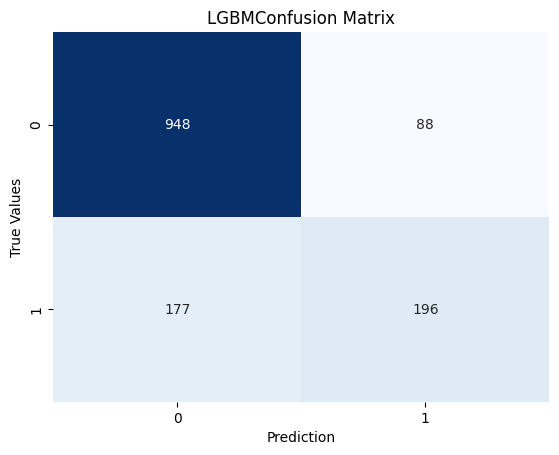

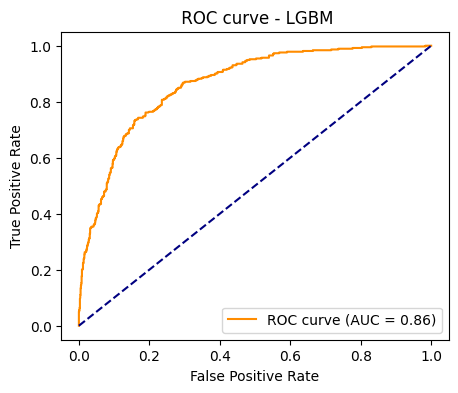

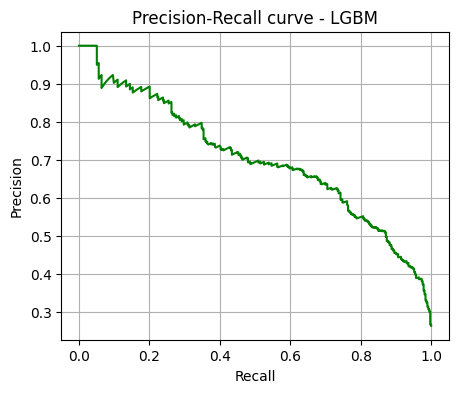

In [26]:
evaluate_model("LGBM",lgbm_final,X_test,y_test)

## 3.6 Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
#logistic regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

ModelLogisticRegression
Accuracy0.8204400283889283
Classification Report
Name:LogisticRegression
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

Confusion Matrix
Name:LogisticRegression


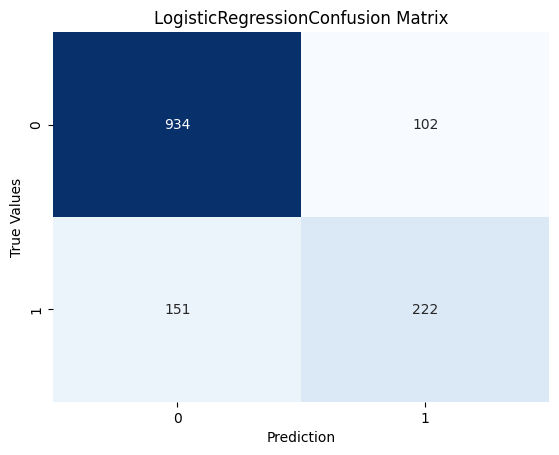

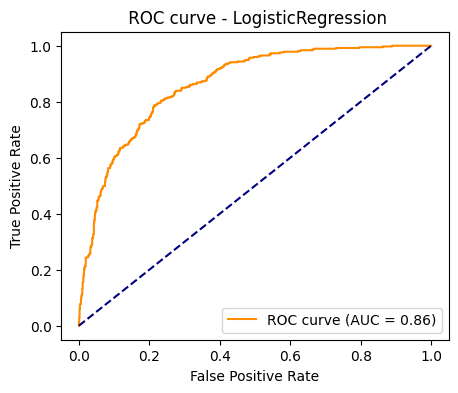

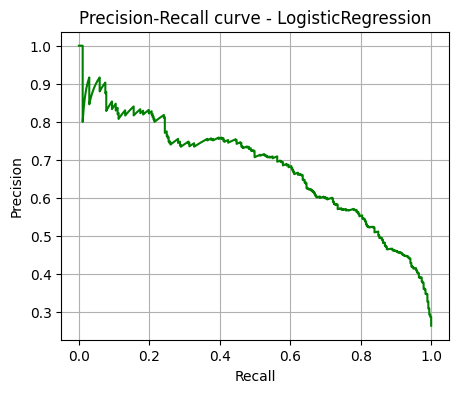

In [28]:
evaluate_model("LogisticRegression",lr,X_test,y_test)

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# 4. Set up the grid search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='accuracy',  # The evaluation metric
    cv=5,                # Number of cross-validation folds
    n_jobs=-1,           # Use all available CPU cores
    verbose=1
)

# 5. Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# 6. Print the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", 

Best parameters found:  {'C': 10, 'penalty': 'l2'}
Best accuracy score:  0.8020951897632942


In [30]:
paramlr = {'C': 10, 'penalty': 'l2'}
lr_final = LogisticRegression(**paramlr,random_state=42)
lr_final.fit(X_train, y_train)

LogisticRegression(C=10, random_state=42)

ModelLogisticRegression
Accuracy0.8190205819730305
Classification Report
Name:LogisticRegression
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409

Confusion Matrix
Name:LogisticRegression


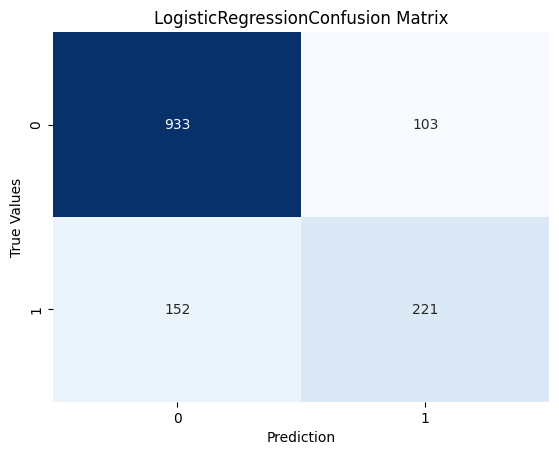

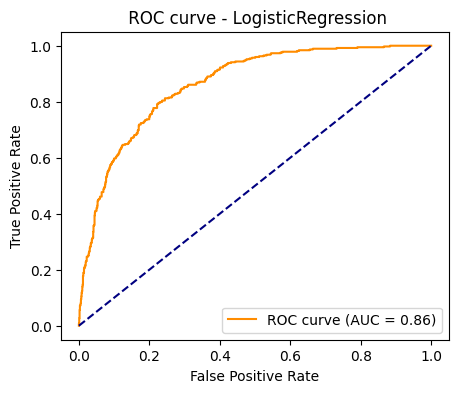

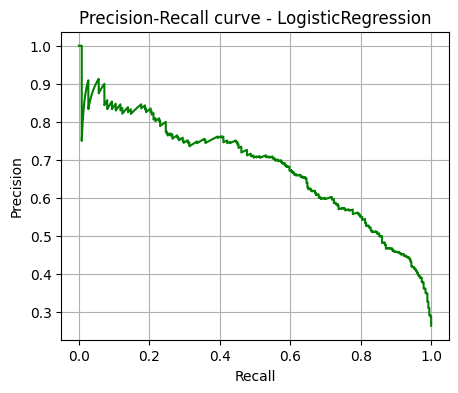

In [31]:
evaluate_model("LogisticRegression",lr_final,X_test,y_test)

Conclusion ▶


*   Overfitting




##3.8 SVM Model Final Model

In [32]:
from sklearn.svm import SVC
linear_svm_model = SVC(kernel='linear',random_state=42)
linear_svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

ModelSVM
Classification Report
Name:SVM
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

Confusion Matrix
Name:SVM


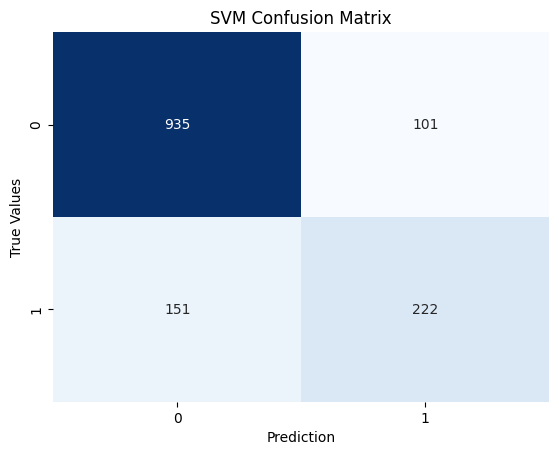

In [33]:
y_pred = linear_svm_model.predict(X_test)
# Acuuracy
print(f"ModelSVM")
  # Classification
print("Classification Report")
print(f'Name:SVM')
print(classification_report(y_test,y_pred))

  # Confusion Matrix
print("Confusion Matrix")
cm = confusion_matrix(y_test,y_pred)
print(f'Name:SVM')
sns.heatmap(cm,annot = True,fmt="d", cmap="Blues", cbar=False)
plt.title(f"SVM Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("True Values")
plt.show()

In [34]:
# 3. Define the parameter grid to search through
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced']  # Handles imbalanced data
}

# 4. Set up the grid search
grid_search = GridSearchCV(
    estimator=linear_svm_model,
    param_grid=param_grid,
    scoring='f1',        # A better metric for imbalanced data
    cv=5,                # Number of cross-validation folds
    n_jobs=-1,           # Use all available CPU cores
    verbose=1
)

# 5. Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# 6. Print the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best f1 score: ", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters found:  {'C': 0.01, 'class_weight': 'balanced'}
Best f1 score:  0.594625975506361


## Conclusion ▶
Conclusion ▶
Best Predicting Model Untill now .

Classification Report :
*   **Accuracy** is 82 % says We will predict Churn correctly 8 out of 10 times.
*   **Class 0**  Precision is (80) and recall is (90) indicates model is really good at predicting person who will stay.
*   **Class 1** Precision (69) and recall (60) Indicates model strugles to find person who will leave.


Confusion Matrix :
*   **Class 0** 935 Correct Prediction and 151 wrong Prediction.
*   **Class 1** 222 correct and 101 wrong .





#4- Conclusion ▶


---


**Now We have A Model To predict behavior of customer Churn What we can do with it ?**

* *Focus on class 1 and give them offers Like:*
    * Reasonable Discount on Contracts of 1 to 2 years because they have more chances of staying.
    * People with fiber optic services are more tend to leave understand what is the reason behind it, improve the service.
* *Churn 0 :*
    * People with Two and 1 year tenure and contracts have more tend to stay.
    * Senior Citzen and pustomer with dependents and partners are more tend to stay.

*The Model Is build to predict Chrurn 1 and prevent lossing customers to make a steady and improving growth for the firm.*


---


**Imporvements :**
* *Data :* We need more data about churn 1 which make more accurate predictions.



* There are some unknown reasons people leave in two year and 1 year or bigger tenure there is chance they got some better offers or move out . It also can be problem of less features.